# Report on MPW2 - Computational graphs (CG)

# Done by
* Student 1: Iuliia Demidova (iuliia.demidova@students.fhnw.ch)
* Student 2: Lucas Keller (lucas.keller@students.fhnw.ch)


In [5]:
import sys
from pathlib import Path
# fixing imports for src/ modules
sys.path.append(str(Path().resolve().parents[1])) 
# I had to add this section above for importing the src modules (Lucas)

import random
import pandas as pd
import numpy as np
from numpy import dtype
from numpy.linalg import inv
import matplotlib.pyplot as plt

from src.cg import cg_paths
from src.cg.cgnodes import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

# 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](./images/simple-graph-1.jpg)

In [6]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


--------

## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [7]:
datadir = cg_paths.DATA_DIR
datafile = datadir / "lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [8]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [9]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend, 
# also optional.
def plot_data_prediction(
        x_points,
        y_points,
        x_curve=None,
        y_curve=None,
        x_title='x',
        y_title='y',
        theta_0=None,
        theta_1=None,
        theta_2=None,
        title=None,):
    if title is None:
        plt.title("{} as a function of {}".format(y_title, x_title))
    else:
        plt.title(title)
    plt.xlabel(x_title)   # ex "Living area (m^2)"
    plt.ylabel(y_title)   # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = fr"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += fr", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

# similar method for 2nd order model
def plot_data_prediction_squared(
    x_points,
    y_points,
    x_curve=None,
    y_curve=None,
    x_title="x",
    y_title="y",
    theta_0=None,
    theta_1=None,
    theta_2=None,
    title=None,
):
    if title is None:
        plt.title(f"{y_title} as a function of {x_title}")
    else:
        plt.title(title)

    plt.xlabel(x_title)
    plt.ylabel(y_title)

    plt.scatter(x_points, y_points, s=10, label="data")

    # If curve is not provided, build it from theta values
    if x_curve is None:
        x_curve = np.linspace(np.min(x_points), np.max(x_points), 300)

    if y_curve is None:
        if theta_0 is None or theta_1 is None or theta_2 is None:
            raise ValueError(
                "Either provide x_curve and y_curve, or provide theta_0, theta_1, theta_2."
            )
        y_curve = theta_0 + theta_1 * x_curve + theta_2 * (x_curve ** 2)

    model_label = "2nd order model"

    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label = (
            fr"model ($\theta_0={theta_0:.3f}$, "
            fr"$\theta_1={theta_1:.3f}$, "
            fr"$\theta_2={theta_2:.6f}$)"
        )

    plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()


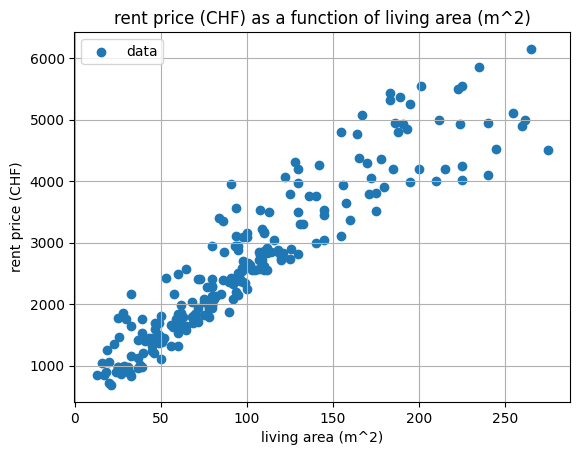

In [10]:
plot_data_prediction(living_area, rent_price, x_title='living area (m^2)', y_title='rent price (CHF)')

---------

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows (**Eq. (1)**):

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}


We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by (**Eq. (2)**):

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}


This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following (**Eq. (3)**):

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}



intercept (theta_0): 657.6890591150308
slope (theta_1)    : 19.661179947454308


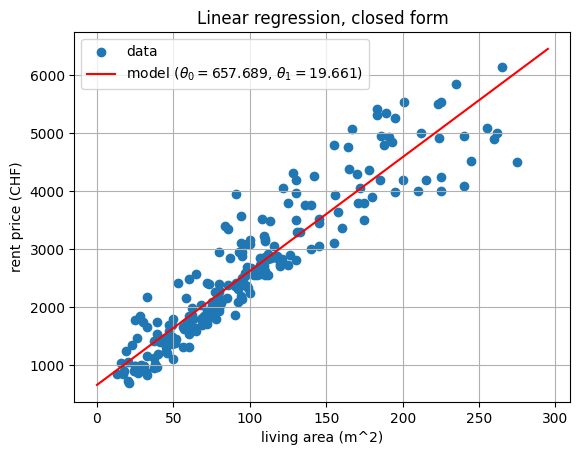

In [11]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta = np.linalg.solve(X.T @ X, X.T @ y)
# also may be used:
# theta, *_ = np.linalg.lstsq(X, y, rcond=None)

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title='living area (m^2)',
    y_title='rent price (CHF)',
    theta_0=theta[0],
    theta_1=theta[1],
    title="Linear regression, closed form"
)


<div class="alert alert-block alert-warning">
<b>Note:</b> The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
</div>

1. Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area.
2. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [12]:
def mse_loss(y_hat, y):
    # This is the MSE loss from Eq. 2 above, which is not standard MSE formula.
    # For standard MSE, there is no `/2` in the end.
    return np.mean((y_hat - y) ** 2) / 2

y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.1305691358


* This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression).
* Another frequently used metric is the **root mean squared error (RMSE) which is the square root of the MSE**. It is in the same unit as the target variable and is easier to interpret.

* Other commonly used metrics are the **mean absolute error (MAE) and the mean absolute percentage error (MAPE)**.
    * MAE is the average of the absolute differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE.
    * MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

In [13]:
def rmse_loss(y_hat, y):
    # Here, we use a standard MSE value, without /2 operation
    # See explanation of RMSE>=MAE and link in the next cell
    return np.sqrt(np.mean((y_hat - y) ** 2))

def mae_loss(y_hat, y):
    return np.mean(np.abs(y_hat - y))

def mape_loss(y_hat, y):
    return np.mean(np.abs((y_hat - y) / y))

rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
avg_price = np.mean(y)
median_price = np.median(y)
print("The total value of the RMSE loss is", f"{rmse:.3f}")
print("The total value of the MAE loss is", f"{mae:.3f}")
print("The total value of the MAPE loss is", f"{mape_percent:.2f}%")
# print("Mean rent price is", f"{avg_price:.3f}")
# print("Median rent price is", f"{median_price:.3f}")
# print("Mean living area is", f"{np.mean(living_area):.3f}")
# print("Median living area is", f"{np.median(living_area):.3f}")

The total value of the RMSE loss is 458.072
The total value of the MAE loss is 347.377
The total value of the MAPE loss is 14.63%


## Functions implementation
1. [x] Implement the functions above to compute the **MSE, RMSE, MAE and MAPE losses**.
2. [x] Compute these losses for the linear regression model with the optimal $\theta$ obtained above.
3. [x] Interpret the results.
### Interpretation of the results
1. `MSE_loss = 104915.1305691358`: Average squared error measured in $CHF^2$, based on Equation 2.
2. `RMSE_loss = 458.377`: This value is the square root of the `MSE_loss`, so it is measured in CHF and gives an idea of the average error of the model in terms of rent price.

    In geometric terms, RMSE is related to the $L_2$ norm of the residual vector, normalized by $\sqrt{n}$

3. `MAE_loss = 347.377`: This value is the average of the absolute differences between the predicted values and the actual values, so it is also measured in CHF. It gives an idea of the average error of the model in terms of rent price, but it is less sensitive to outliers than the MSE, because the errors are not squared.

   In geometric terms, MAE is related to the $L_1$ norm of the residual vector, normalized by $n$.
   > See below: $RMSE \ge MAE $ rule.
4. `MAPE_loss = 14.63%`: This value is the average of the absolute **percentage differences** between the predicted values and the actual values, so it is a **relative error metric**. It gives an idea of the average error of the model in terms of percentage of the actual rent price. It is useful when the target variable has a wide range of values, as it **normalizes the error by the actual value**.

See https://en.wikipedia.org/wiki/Norm_(mathematics) for more details about the $L_1$ and $L_2$ norms.


## Extra question
**What could be the problem with MAPE ?**
### Answer
**MAPE loss can be problematic when the actual values are close to zero**, as the `mape_loss` function includes division by `y`. This can lead to large percentage errors.

In our case, the average rent price is 2594.273 CHF, so the MAPE loss of 14.63% means that on average, the predicted rent prices are off by around 14.63% of the actual rent prices. This can be interpreted as the model being off by around 380 CHF on average, which is consistent with the RMSE and MAE losses we computed above. However, if we had some actual rent prices that were close to zero, the MAPE loss could be very large and not very informative about the performance of the model.

## See also
Explanation why we use Standard MSE formula in RMSE loss function ($RMSE \ge MAE $ inequality): https://mathcircle.berkeley.edu/sites/default/files/archivedocs/1999_2000/lectures/9900lecturespdf/inequalities.pdf
<div class="alert alert-block alert-warning">
 $P_1$ is an arithmetic mean, $P_2$ is the root mean square. For $r>s>0$, $P_r \ge P_s$
</div>


---------

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](./images/linear-regression-graph.jpg)

- [x] TO COMPLETE:
    Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values.
    - The node should have two inputs: the predicted values and the actual values.
    - The node should have one output: the MSE loss.

Then you can create the graph below.

In [14]:
# first create all ValueNode objects
theta_0_node = ValueNode()
theta_1_node = ValueNode()
y_node = ValueNode()
x_node = ValueNode()
q_node = ValueNode()
y_hat_node = ValueNode()
j_node = ValueNode()

# then create all <Operator>Node objects
mult_node = MultiplyNode(x_node, theta_1_node, q_node)
sum_node = AddNode([q_node, theta_0_node], y_hat_node)
loss_node = MSELossNode(y_hat_node, y_node, j_node)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x_node, theta_0_node, theta_1_node, y_node], [j_node])

In [15]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j_node.v)  # should give 0.5

0.5


In [16]:
cg.backward()
print(theta_0_node.grad_v, theta_1_node.grad_v)  # should give -1.0 -0.0


-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [17]:
# this function plots the evolution of the loss and the parameters during training, as well 
# as the data points and the model curve at the end of training. The last value of the 
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y, title=''):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,7))

    fig.suptitle('Training log ' + title)
    ax1.plot(t0_evolution)

    ax1.set_title('theta 0')
    ax2.plot(t1_evolution)

    ax2.set_title('theta 1')
    ax3.plot(loss_evolution)

    ax3.set_title('loss')
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color='red')
    ax4.set_title('points and model output')
    fig.tight_layout()

# similar function, but to plot 2nd order model curves
def plot_training_log_squared(
    loss_evolution,
    t0_evolution,
    t1_evolution,
    t2_evolution,
    x,
    y,
    title=''
):
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(
        2, 3, figsize=(14, 7)
    )

    fig.suptitle('Training log (2nd order) ' + title)

    # theta evolutions
    ax1.plot(t0_evolution)
    ax1.set_title('theta 0')

    ax2.plot(t1_evolution)
    ax2.set_title('theta 1')

    ax3.plot(t2_evolution)
    ax3.set_title('theta 2')

    # loss
    ax4.plot(loss_evolution)
    ax4.set_title('loss')

    # data + quadratic model curve
    ax5.scatter(x, y, s=1.0)

    x_curve = np.linspace(np.min(x), np.max(x), 200)

    t0 = t0_evolution[-1]
    t1 = t1_evolution[-1]
    t2 = t2_evolution[-1]

    y_curve = t0 + t1 * x_curve + t2 * (x_curve ** 2)

    ax5.plot(x_curve, y_curve, color='red')
    ax5.set_title('points and model output')

    # unused panel
    ax6.axis('off')

    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions. 

intercept (theta_0): 1.0008950644989494
slope (theta_1)    : 24.515040275412407
The total value of the loss is  163431.99821365392
The total value of the RMSE loss is 571.720
The total value of the MAE loss is 413.271
The total value of the MAPE loss is 17.35%


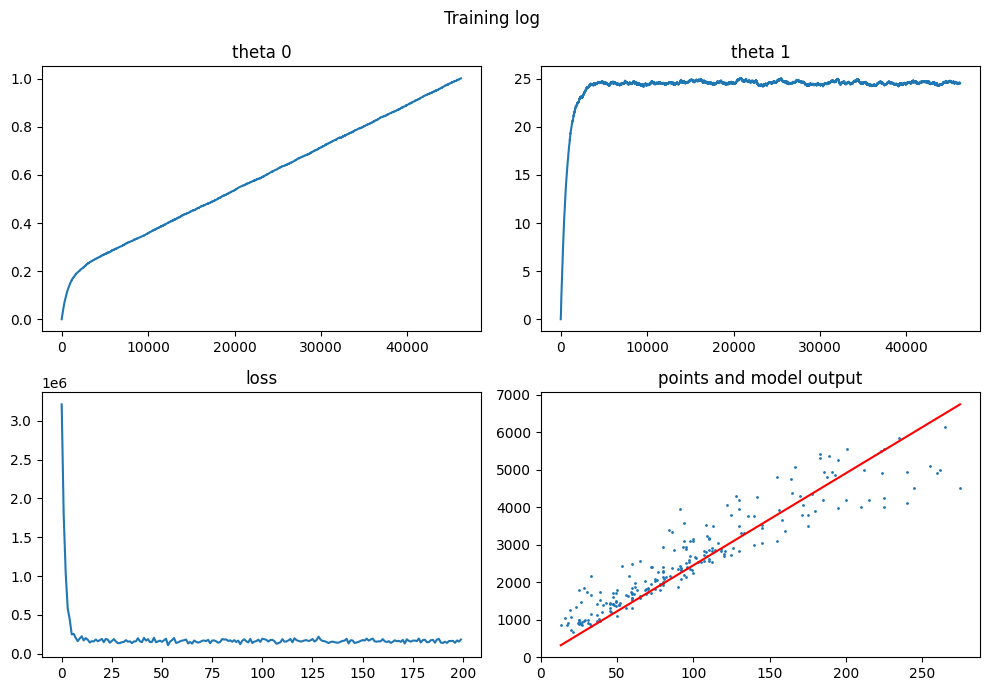

In [18]:
alpha = 1e-7    # learning rate
epochs = 200          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()

        t0 -= alpha * theta_0_node.grad_v
        t1 -= alpha * theta_1_node.grad_v

        epoch_loss += j_node.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is ", J)
rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)
print("The total value of the RMSE loss is", f"{rmse:.3f}")
print("The total value of the MAE loss is", f"{mae:.3f}")
print("The total value of the MAPE loss is", f"{mape * 100 :.2f}%")

plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)



### Theoretical evaluation of gradients
Let's define **order of magnitude** notation (non-standard and not rigorous, but useful for our analysis) as follows:
$$
\operatorname{ord}(x) = 10^{\lfloor \log_{10} |x| \rfloor}
$$

For example: $ord(56)=10$, $ord(7839)=10^3$, etc.

Definition of the loss function and the predicted value:
\begin{equation*}
J = \frac{1}{2}(\hat{y}-y)^2)
\end{equation*}


\begin{equation*}
\hat{y} = \theta_0 + \theta_1 x = \theta_0 + q
\end{equation*}

**From the dataset, order of magnitude for $x$ and $y$ values are the following**:
\begin{equation*}
MinOrd(x) = 10, MaxOrd(x) = 10^2, MinOrd(y) = 10^2, MaxOrd(y) = 10^3
\end{equation*}

For $\theta_1$, gradient is the following:
\begin{equation*}
\frac{dJ}{d\theta_1} = \frac{1}{2}(2x^2\theta_1 + 2x\theta_0 +0 -2xy -0 +0) = x^2\cdot\theta_1 + x \cdot \theta_0 - x \cdot y
\end{equation*}


\begin{equation*}
\rightarrow MinOrd(\frac{dJ}{d\theta_1}) = MinOrd(10^2\cdot\theta_1 + 10 \cdot \theta_0 - 10 \cdot 10^2) = 10^3
\end{equation*}
\begin{equation*}
\rightarrow MaxOrd(\frac{dJ}{d\theta_1}) = MaxOrd(10^4\cdot\theta_1 + 10^2 \cdot \theta_0 - 10^2 \cdot 10^3) = 10^5
\end{equation*}

For $\theta_0$, gradient is the following:
\begin{equation*}
\frac{dJ}{d\theta_0} = \frac{1}{2}(0+2\theta_1 x + 2\theta_0-0-2y+0) = \theta_1 x + \theta_0 - y
\end{equation*}

\begin{equation*}
\rightarrow MinOrd(\frac{dJ}{d\theta_0}) = MinOrd(\theta_1 \cdot 10 + \theta_0 - 10^2) = 10^2
\end{equation*}
\begin{equation*}
\rightarrow MaxOrd(\frac{dJ}{d\theta_1}) = MaxOrd(\theta_1 \cdot 10^2 + \theta_0 - 10^3) = 10^3
\end{equation*}



<div class="alert alert-block alert-info"> <b>Conclusion:</b> the gradients of $\theta_1$ have order of $10^3...10^5$, while the gradients of $\theta_0$ have the order of $10^2...10^3$. This means that $\theta_1$ will evolve significantly faster than $\theta_0$.</div>

### Our observations (`epochs=200`, `LR = 1e-7`)
The red regression line has a visibly reasonable slope, but it is vertically misplaced. It passes too close to the origin because the intercept is almost zero.

Comparison table between closed form and plain vanilla SGD (only approximate values for several repeated experiments):

| Value               | Closed form | Vanilla SGD |    Difference |
|---------------------|------------:|------------:|--------------:|
| `theta_0` intercept |     657.689 |       ~ 1.0 |        ~ -656 |
| `theta_1` slope     |      19.661 |    ~ 24..25 |     ~ +5...+6 |
| RMSE                |     458.072 |       ~ 572 |        ~ +114 |
| MAE                 |     347.377 | ~ 408...415 |   ~ +60...+67 |
| MAPE                |      14.63% |       ~ 17% |     ~ +2.4 pp |
| Loss                |  104'915.13 |  ~ 150-172K | ~ +45K...+67K |


#### Evolution of the `Loss`
- The loss starts from a value of around $3 \cdot 10^6$ and quickly drops below $0.25 \cdot 10^6$ after around 6-7 epochs. This means Vanilla SGD finds a much better region than the zero-initialized model almost immediately.
- Loss oscillates in range `~ 150-172K` by the end of training, instead of approaching the reference value of `104,915.13`. This suggests that the loss has not converged to the reference result.

#### Evolution of `theta_1`

- We can see a stabilization of `theta_1` in a range around `24.0...25.0` after 6-7 epochs, which is not close enough to the optimal value of `19.661` obtained with the closed form solution.
- However, this value is __at least in the same scale__ as the optimal coefficient ($ord(19.661)=10$ vs $ord(24.0)=10$), unlike for `theta_0`.

#### Evolution of `theta_0`:

Starting from `0.0`, `theta_0` shows **a very slow evolution**, reaching only around `1.0` after 200 epochs, which is **very far from the optimal value of `657.689`** obtained with the closed form solution. Reasons for that are explained in the theoretical evaluation of gradients above, and are the following:
- The learning rate $\alpha=10^{-7}$ is very small. With unnormalized `living_area`, a much larger learning rate may make `theta_1` unstable, so the small learning rate keeps training stable but slows convergence.
- The gradients for `theta_0` are roughly on the scale of $10^2...10^3$. With learning rate $\alpha = 10^{-7}$, one SGD update for `theta_0` is therefore roughly on the scale of:

$$
MaxOrd=10^{-7} \cdot 10^3 = 10^{-4}, MinOrd=10^{-7} \cdot 10^2 = 10^{-5}
$$

Since one epoch contains $N = 231, ord(231)=10^2$ sample updates and training runs for 200 epochs ($ord(200)=10^2$), the total number of updates is:

$$
10^2 \cdot 10^2 = \cdot 10^4
$$

So a rough order of magnitude estimate for the total movement of `theta_0` is:

$$
MaxOrd=10^{-4} \cdot 10^4 = 1
$$
$$
MinOrd=10^{-5} \cdot 10^4 = 10^{-1}
$$

In practice, the observed value is `theta_0 ~ 1.0` ($ord(1)=1$), which is plausible because gradients are not constant.
>The estimate is consistent with the theoretical conclusions and the observed value: $0.1<ord(1.0)=1$


### Our observations (`epochs=70'000`, `LR = 1e-6`)
In order to achieve approximate convergence of Vanilla SGD to the closed form solution reference values, we tried to increase the LR and the number of epochs to get closer to the optimal `theta_0`, `theta_1`, and loss. After several experiments, we found that with a LR of $10^{-6}$ and 70'000 epochs, SGD approaches the closed form solution (reference). The results are summarized in the table below.

Comparison table between closed form solution and plain Vanilla SGD (only approximate values for several repeated experiments):

| Value               | Closed form solution |  Vanilla SGD | Difference |
|---------------------|---------------------:|-------------:|-----------:|
| `theta_0` intercept |              657.689 |        ~ 650 |       ~ -9 |
| `theta_1` slope     |               19.661 |    ~ 18...22 |       ~ ±2 |
| RMSE                |              458.072 |        ~ 459 |       ~ +1 |
| MAE                 |              347.377 |    ~ 343-351 |       ~ ±4 |
| MAPE                |               14.63% |  ~ 14%...15% |  ~ ±1 p.p. |
| Loss                |           104'915.13 | ~ 105...108K | ~ +0K...3K |

#### Evolution of the `Loss`

- The loss starts from a value of around $0.8 \cdot 10^6$ and drops to range between of $0.2...0.3 \cdot 10^6$ after around 10'000 epochs.
- The loss value is still huge (~ 105-108K), for reasons mentioned before. However, it is much closer to the reference value of 104'915.13, compared to the previous result where the loss was ~ 176K.

#### Evolution of `theta_1`

$\theta_1$ gradually stabilizes in the range `18.0...22.0` after ~30'000 epochs, approaching the reference value of `19.661`.
The remaining spread ~ 18–22 reflects stochastic fluctuations of SGD around the optimum.

#### Evolution of `theta_0`:


Starting from `0.0`, `theta_0` shows **clear convergence towards the optimum**, having a value of `~ 650` by the end of the training.
- The learning rate $\alpha=10^{-6}$ is still small, but it allows to speed up the convergence of `theta_0` compared to the previous experiment.
- The gradients for `theta_0` are roughly on the scale of $10^2...10^3$. With learning rate $\alpha = 10^{-6}$, one SGD update for `theta_0` is therefore roughly on the scale of:

$$
MaxOrd=10^{-6} \cdot 10^3 = 10^{-3}, MinOrd=10^{-6} \cdot 10^2 = 10^{-4}
$$

Since one epoch contains $N = 231$ ($ord(231)=10^2$) sample updates and training runs for 70'000 epochs ($ord(70000)=10^4$), the total number of updates is:

$$
10^4 \cdot 10^2 = 10^6
$$

So a rough order of magnitude estimate for the total movement of `theta_0` is:

$$
MaxOrd=10^{-3} \cdot 10^6 = 10^3=1000, MinOrd=10^{-4} \cdot 10^6 = 10^2=100
$$

In practice, the observed value is `~ 650`, which is plausible because gradients are not constant.
>The estimate is consistent with the theoretical conclusions and the observed value: $100 = ord(650) < 1000$




<div class="alert alert-block alert-info">
<b>Conclusion:</b> This experiment shows that Vanilla SGD can approximate the closed form solution, but only with a specifically chosen LR and large number of updates, especially when the inputs are not normalized.
</div>


### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm.
- The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

intercept (theta_0): 0.4664404995225834
slope (theta_1)    : 24.474203465610266
The total value of the loss is 163542.91712061624
The total value of the RMSE loss is 571.914
The total value of the MAE loss is 414.468
The total value of the MAPE loss is 17.42%


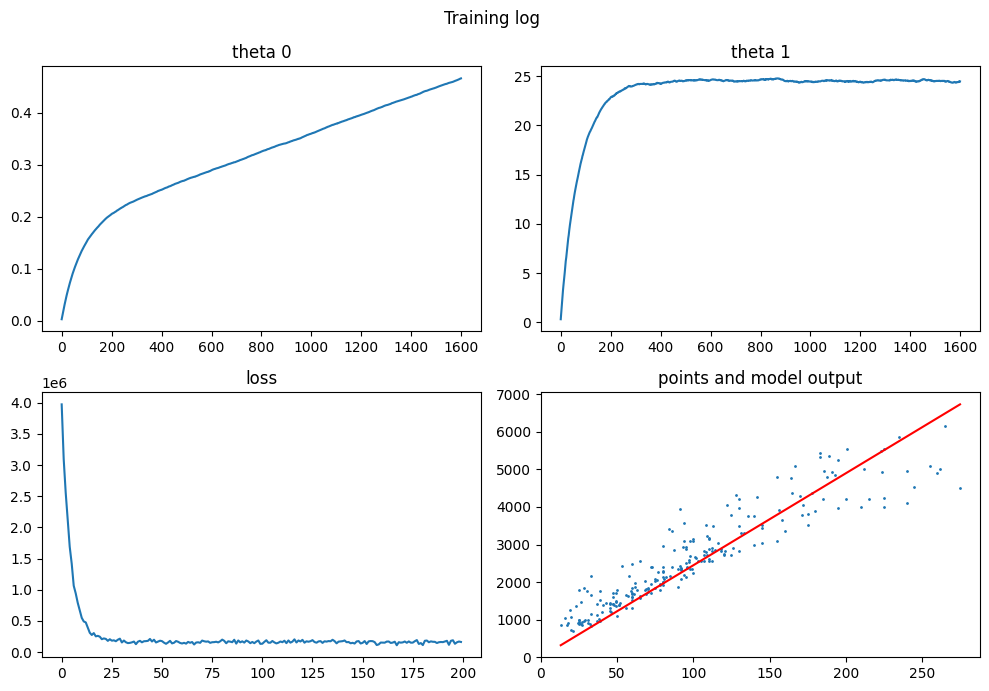

In [19]:
# initial values are alpha=1e-6, epochs=200
alpha = 1e-6  # learning rate can be higher than in the plain vanilla SGD
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for step in range(n_steps):

        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        # working with a batch of samples
        for _ in range(batch_size):
            n = random.choice(range(0, N))

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()

            batch_grad_t0 += theta_0_node.grad_v
            batch_grad_t1 += theta_1_node.grad_v
            batch_loss += j_node.v

        # average gradients over the batch
        batch_grad_t0 /= batch_size
        batch_grad_t1 /= batch_size
        batch_loss /= batch_size

        # update parameters once per batch
        t0 -= alpha * batch_grad_t0
        t1 -= alpha * batch_grad_t1

        epoch_loss += batch_loss

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)
print("The total value of the RMSE loss is", f"{rmse:.3f}")
print("The total value of the MAE loss is", f"{mae:.3f}")
print("The total value of the MAPE loss is", f"{mape * 100 :.2f}%")


plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

### Curves comparison: Vanilla SGD vs Batched GD
| Vanilla SGD (LR=1e-7, epochs=200) | Batched GD (LR=1e-6, epochs=200) | Batched GD (LR=1e-5, epochs=200)                                   |
|:-------------------------------------------------------------------|:-------------------------------------------------------------------|:-------------------------------------------------------------------|
| 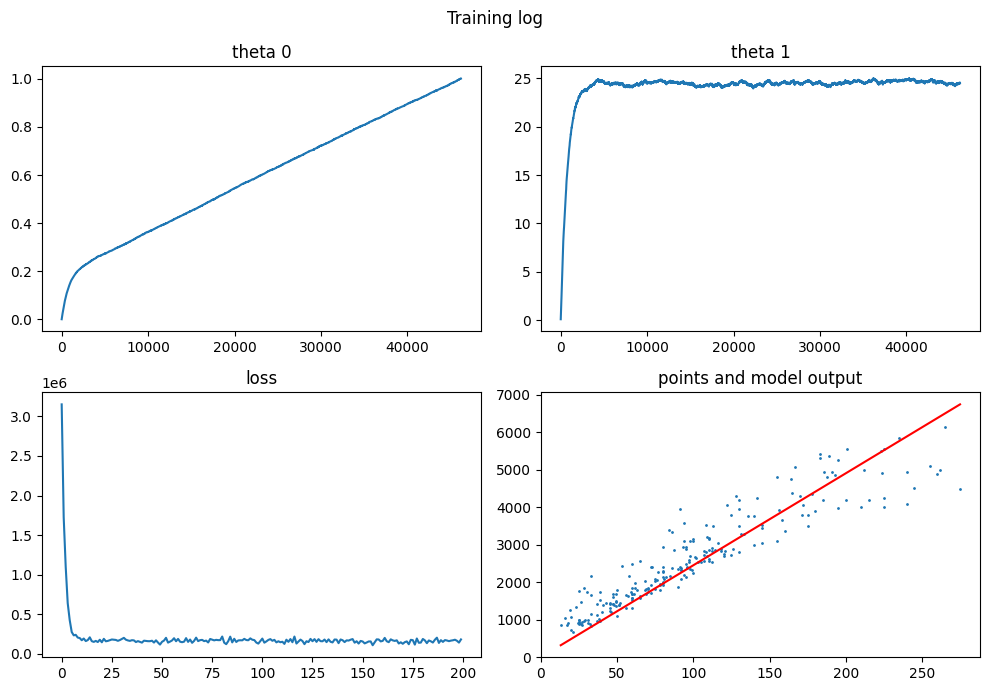 | 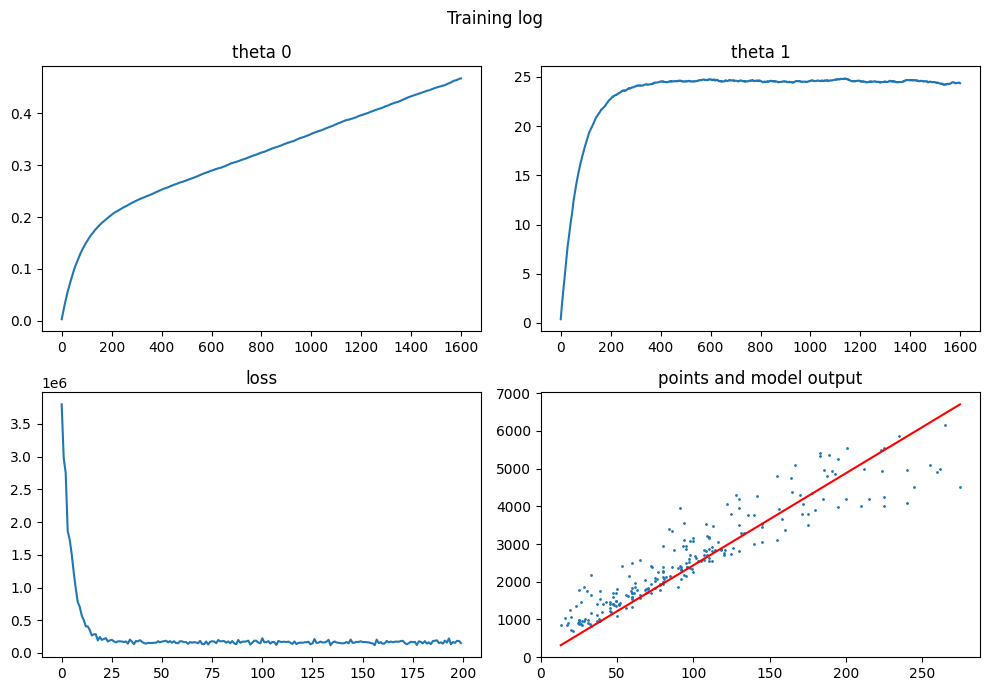 | 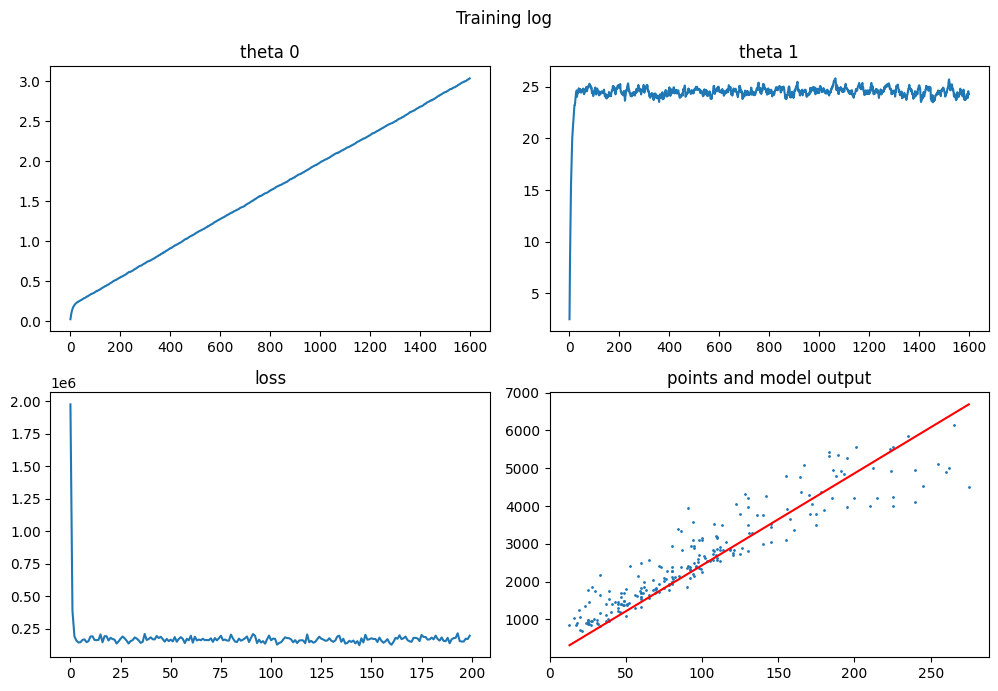  |



### Our observations

Comparison table between plain Vanilla SGD and Batched GD (only approximate values for several repeated experiments):

| Value               | Closed form solution |   Vanilla SGD |    Batched GD |
|---------------------|---------------------:|--------------:|--------------:|
| epochs              |                    - |           200 |           200 |
| LR                  |                    - |      **1e-7** |      **1e-6** |
| `theta_0` intercept |              657.689 |         ~ 1.0 |        ~ 0.47 |
| `theta_1` slope     |               19.661 |      ~ 24..25 | ~ 24.4...24.5 |
| RMSE                |              458.072 |         ~ 572 |         ~ 572 |
| MAE                 |              347.377 |   ~ 408...415 |   ~ 412...416 |
| MAPE                |               14.63% |         ~ 17% |       ~ 17.5% |
| Loss                |           104'915.13 | ~ 150K...172K |  ~ 163...164K |


#### Evolution of `theta_0`
Starting from `0.0`, `theta_0` shows **a very slow evolution**, reaching only around `0.47` after 200 epochs, which is **very far from the optimal value of `657.689`** obtained with the closed form solution. Reasons for that are explained in the theoretical evaluation of gradients above, and are the following:
- The learning rate $\alpha=10^{-6}$ is very small. With unnormalized `living_area`, a much larger learning rate may make `theta_1` unstable, so the small learning rate keeps training stable but slows convergence.

- The gradients for `theta_0` are roughly on the scale of $10^2...10^3$. LR $\alpha = 10^{-6}$.
For Batched GD, Since one epoch contains $\lfloor\frac{231}{32}\rfloor+1 = 8$ sample updates and training runs for 200 epochs, the total number of updates is:

$$
8 \cdot 200 = 1600, ord(1600)=10^3
$$

So a rough order of magnitude estimate for the total movement of `theta_0` is:

$$
MaxOrd=10^{3} \cdot 10^{-6} \cdot 10^3 = 10^0=1
$$
$$
MinOrd=10^{2} \cdot 10^{-6} \cdot 10^3 = 10^{-2}=0.1
$$

In practice, the observed value is `theta_0 ~ 0.47` ($ord(0.47)=0.1$), which is plausible because gradients are not constant.
>The estimate is consistent with the theoretical conclusions and the observed value: $0.1=ord(0.47)<1$


#### Evolution of `theta_1`
- We can see a stabilization of `theta_1` in a range around `24.0...25.0` (similar to Vanilla SGD) after 15-19 epochs, which is not close enough to the optimal value of `19.661` obtained with the closed form solution. However, this value is __at least in the same scale__ as the optimal coefficient ($ord(19.661)=10$ vs $ord(24.0)=10$), unlike for `theta_0`.
- Compared to the previous experiment with Vanilla SGD (`LR=1e-7`,`epochs=200`), `theta_1` shows a similar behavior, but it is more stable, as it oscillates around `24.5` by the end of the training.


#### Main conclusion on Batched GD
Noted trade-off:
- Vanilla SGD: many noisy updates $\rightarrow$ faster movement BUT unstable
- Batched GD: fewer, smoother updates $\rightarrow$ more stable BUT slower

In this case, the reduction in the number of updates dominates, leading to slower convergence, especially for `theta_0`.

#### Questions
>**Question 1:** Do we still have the same observation as in the plain stochastic version regarding the convergence of `theta_1` and the slow evolution of `theta_0`?

**Answer:**
Yes, the same behavior is observed:
- `theta_1` still evolves much faster than `theta_0`, due to larger gradients, which is consistent with the theoretical evaluation of gradients we did before.
- `theta_0` evolves even slower than in Vanilla SGD.

This slowdown is explained by the reduced number of parameter updates in Batched GD. While each update uses a more stable (averaged) gradient, the total number of updates is smaller, which slows down learning.

This result was expected, as we are using batches, so each epoch has `n_steps = N // batch_size + 1` updates of `theta_0`, `theta_1`, and loss:
- Previous total number of updates: $epochs \cdot N = 200 \cdot 231 = 46200$
- Current total number of updates: $epochs \cdot \frac{N}{BatchSize} = 200 \cdot (\frac{231}{32} + 1) = 1600$

>**Question 2:** Can we use larger learning rates than in the plain stochastic version ?

**Answer:**

Yes, we can use larger learning rates ($10^{-6}...10^{-4}$) than in the plain stochastic version ($10^{-7}$) for `epochs=200`, as we are averaging the gradients over a batch of samples:
- Smaller variance allows bigger LR,
- Gradients order of magnitudes do not change.
Batched GD does not improve convergence **in this setting**, because the reduction in update frequency dominates the benefit of gradient smoothing.
See comparison of curves for Vanilla SGD vs Batched GD with different learning rates below.

However, with `epochs=200`, the problem of both `theta_0` and `theta_1` not converging to the reference values is still present, even with larger learning rates. The reasons for that explained in details above for evolution of `theta_0`.

For example, for the fixed `batch_size=32`, `N=231`, `n_steps=8`, `LR=1e-6`, gradients scale of $10^2...10^3$ and known `theta_0 ~ 658` (reference value, $ord(\theta_0)=10^2$), `n_epochs` should have an order of magnitude of:
- Lower bound:
$$
\frac{ord(\theta_0)}{ord(grad(\theta_0) \cdot \alpha \cdot n)}=\frac{10^2 \cdot 10^6}{10^3 \cdot 1} = 10^5
$$
- Upper bound:
$$
\frac{10^2 \cdot 10^6}{10^2 \cdot 1} = 10^6
$$

to reach a sufficient number of updates.

**Curves comparison for Vanilla SGD vs Batched GD (`LR=1e-6`, `epochs=200`)**
| Vanilla SGD  | Batched GD  |
|:-------------------------------------------------------------------|:-------------------------------------------------------------------|
|![image.png](attachment:d502c96d-15c4-4b21-a5ba-a2a0f5e17472.png)|![image.png](attachment:42075977-8876-42e4-a9ea-23ed0da28b40.png) |


**Curves comparison for Vanilla SGD vs Batched GD (`LR=1e-5`, `epochs=200`)**
| Vanilla SGD  | Batched GD |
|:-------------------------------------------------------------------|:-----------|
|![image.png](attachment:46264322-5e9d-42a9-9211-553d265c981e.png)|    ![image.png](attachment:b0b4e169-cb2c-4467-943f-a5fa2b3a8d64.png)         |
-------

## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$.

We can use a **larger learning rate for $\theta_1$ than for $\theta_0$** as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters **based on the history of the gradients**.

intercept (theta_0): 655.6089580499968
slope (theta_1)    : 19.65670703717612
The total value of the loss is 104918.3436147382
The total value of the RMSE loss is 458.079
The total value of the MAE loss is 346.879
The total value of the MAPE loss is 14.58%


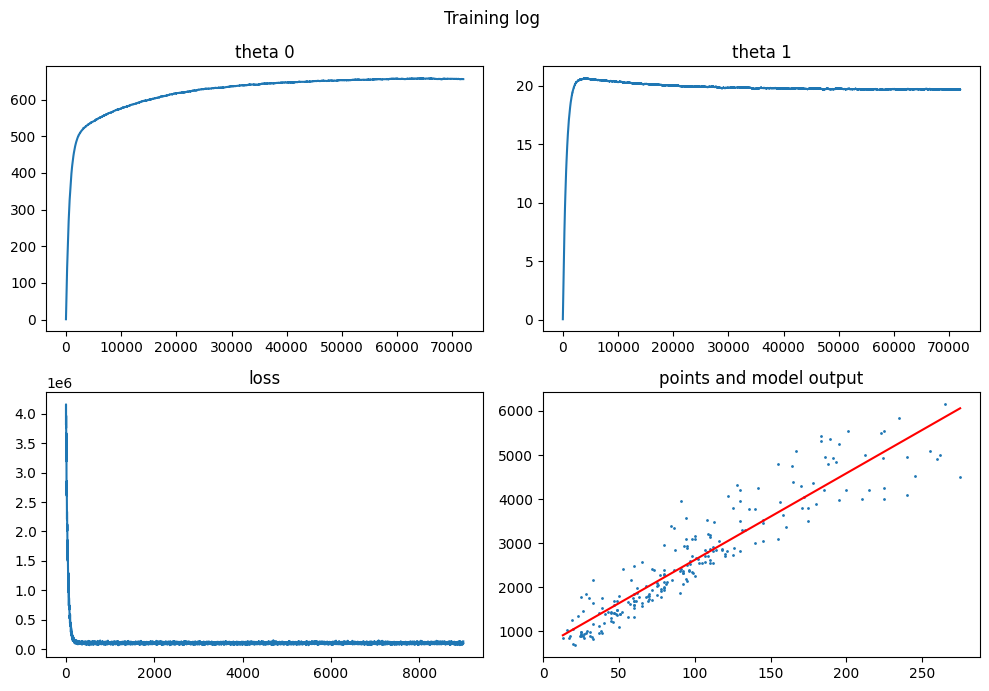

In [20]:
alpha_t0 = 3 * 1e-4    # learning rate for theta_0
alpha_t1 = 1e-7  # learning rate for theta_1
epochs = int(9 * 1e3)          # number of epochs (an epoch is a loop over the whole training set)
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for step in range(n_steps):

        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        # working with a batch of samples
        for _ in range(batch_size):
            n = random.choice(range(0, N))

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()

            batch_grad_t0 += theta_0_node.grad_v
            batch_grad_t1 += theta_1_node.grad_v
            batch_loss += j_node.v

        # average gradients over the batch
        batch_grad_t0 /= batch_size
        batch_grad_t1 /= batch_size
        batch_loss /= batch_size

        # update parameters once per batch
        t0 -= alpha_t0 * batch_grad_t0
        t1 -= alpha_t1 * batch_grad_t1

        epoch_loss += batch_loss

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)
print("The total value of the RMSE loss is", f"{rmse:.3f}")
print("The total value of the MAE loss is", f"{mae:.3f}")
print("The total value of the MAPE loss is", f"{mape * 100 :.2f}%")
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)


### Our observations

As stated before, the orders of magnitude of gradients are as following:

For $\theta_1$, gradient is the following:
\begin{equation*}
\frac{dJ}{d\theta_1} =  x^2\cdot\theta_1 + x \cdot \theta_0 - x \cdot y
\end{equation*}

\begin{equation*}
\rightarrow MinOrd(\frac{dJ}{d\theta_1}) = 10^3
\end{equation*}
\begin{equation*}
\rightarrow MaxOrd(\frac{dJ}{d\theta_1}) = 10^5
\end{equation*}

For $\theta_0$, gradient is the following:
\begin{equation*}
\frac{dJ}{d\theta_0} = \theta_1 x + \theta_0 - y
\end{equation*}

\begin{equation*}
\rightarrow MinOrd(\frac{dJ}{d\theta_0}) = 10^2
\end{equation*}
\begin{equation*}
\rightarrow MaxOrd(\frac{dJ}{d\theta_1}) = 10^3
\end{equation*}


Therefore, the order of magnitude of difference between `theta_0` and `theta_1` gradients is in range $1...10^3$. From that, we can assume that LRs `alpha_t0` and `alpha_t1` should differ at scale of up to $10^3$ to achieve a better convergence.

In practice, we can see that with `alpha_t0 = 3*1e-4` and `alpha_t1 = 1e-7` (`epochs=9000`, `batch_size=32`), `theta_0` shows a much better convergence than in the previous experiment with a single LR (LR of`theta_1` stayed the same).


<div class="alert alert-block alert-info">
<b>Conclusion:</b> using different LRs for differently evolving parameters can help to speed up the convergence of the parameters that have smaller gradients, without making the training unstable in regard of the parameters that have larger gradients.
</div>

See also a comparison table below.

#### Comparison of experiments with results close to the reference values

| Value                     | Closed form solution | Vanilla SGD | Batched GD (different $\alpha$ LRs) |
|---------------------------|---------------------:|------------:|------------------------------------:|
| epochs                    |                    - |      70'000 |                               9'000 |
| LR $\alpha$ of $\theta_0$ |                    - |        1e-6 |                            3 * 1e-4 |
| LR $\alpha$ of $\theta_1$ |                    - |        1e-6 |                                1e-7 |
| Other parameters          |                    - |           - |                      BatchSize = 32 |
| $\theta_0$ intercept      |              657.689 |       ~ 650 |                               ~ 657 |
| $\theta_1$ slope          |               19.661 |     ~ 18-22 |                              ~ 19.7 |
| Loss                      |           104'915.13 |  ~ 105-108K |                               ~105K |
| Time                      |                 < 1s |       ~ 80s |                               ~ 11s |



### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

**The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients.**

If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called ***momentum*** that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned.

The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. **A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.**

In our previous experiments, **the parameter $\theta_0$ has gradients that seem to go always in the same direction.** Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with __gradients that are not always in the same direction__.

This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

intercept (theta_0): 655.0325540704678
slope (theta_1)    : 19.76673112014363
The total value of the loss is 104965.21489721366
The total value of the RMSE loss is 458.182
The total value of the MAE loss is 348.197
The total value of the MAPE loss is 14.70%


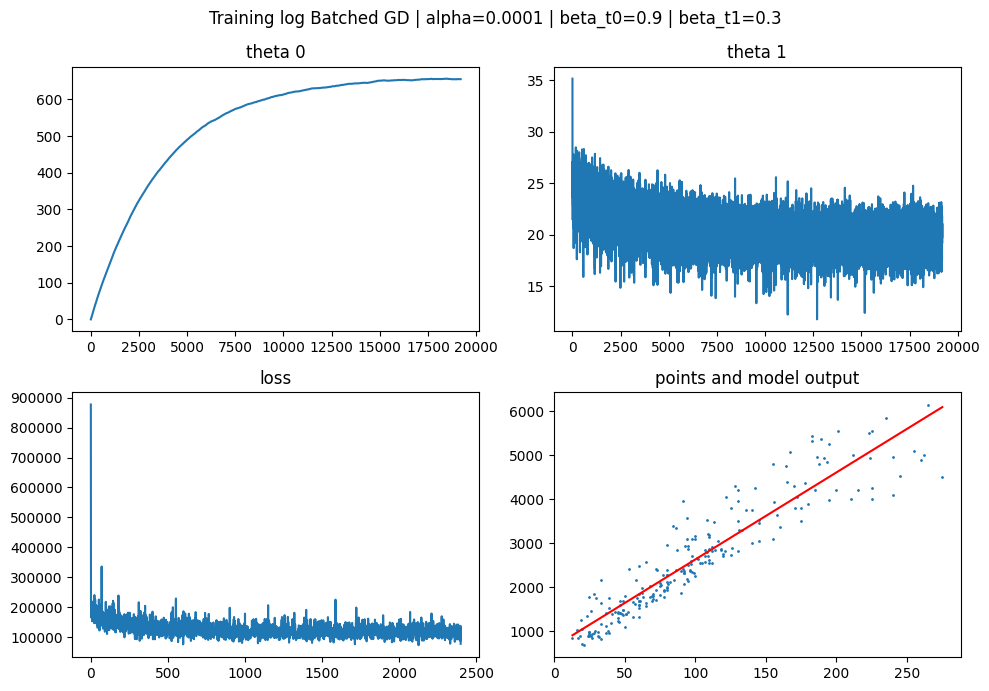

In [21]:
alpha = 1e-4
beta_momentum_t0 = 0.9   # inertia coefficient for theta_0
beta_momentum_t1 = 0.3   # inertia coefficient for theta_1
epochs = 2400            # number of epochs (an epoch is a loop over the whole training set)
momentum_t0 = 0.0       # accumulated update for theta_0
momentum_t1 = 0.0       # accumulated update for theta_1

batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for step in range(n_steps):

        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        # working with a batch of samples
        for _ in range(batch_size):
            n = random.choice(range(0, N))

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()

            batch_grad_t0 += theta_0_node.grad_v
            batch_grad_t1 += theta_1_node.grad_v
            batch_loss += j_node.v

        # average gradients over the batch
        batch_grad_t0 /= batch_size
        batch_grad_t1 /= batch_size
        batch_loss /= batch_size

        # momentum update according to formula
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * batch_grad_t0
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * batch_grad_t1

        # update parameters once per batch
        t0 -= momentum_t0
        t1 -= momentum_t1

        epoch_loss += batch_loss

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)
print("The total value of the RMSE loss is", f"{rmse:.3f}")
print("The total value of the MAE loss is", f"{mae:.3f}")
print("The total value of the MAPE loss is", f"{mape * 100 :.2f}%")

plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price,
                  title="Batched GD | alpha=" + str(alpha) +" | beta_t0=" + str(beta_momentum_t0) + " | beta_t1=" + str(beta_momentum_t1))



## Optional objectives

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

1. [x] Investigate the use of 2nd order model instead of the simple linear model.
2. [ ] Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
3. [ ] Implement an early stopping strategy in your training loop.
4. [ ] Implement a **Learning Rate Decay on Plateau** strategy in the training loop.
5. [x] Normalize the input data with a zero norm approach and compare to your experiments without normalization.


------
# 6 Optional tasks

## 6.1 Data Normalization
The idea is to normalize the input data so it has zero mean and unit standard deviation ($\mu=0$, $\sigma=1$)

This can help to speed up the convergence of the parameters, as it can make the gradients more stable and reduce the risk of exploding or vanishing gradients. It can also help to make the training more stable and less sensitive to the choice of LR.

Standardization of the input data, both predictor and outcome, and scaling back to the original can be done with the following formulas:
$$
x_{scaled} = \frac{x - \mu_x}{\sigma_x}
\quad \rightarrow \quad
x = x_{scaled} \cdot \sigma_x + \mu_x
$$

$$
y_{scaled} = \frac{y - \mu_y}{\sigma_y}
\quad \rightarrow \quad
y = y_{scaled} \cdot \sigma_y + \mu_y
$$

Since the MSE loss $J$ has a square operation, scaling the target by $\sigma_y$ scales the loss by $\sigma_y^2$:
$$
(y-\hat{y})^2 = \sigma_y^2(y_{scaled}-\hat{y}_{scaled})^2 \rightarrow J = \sigma_y^2 \cdot J_{\text{scaled}}
$$
The parameters $\theta_0$ and $\theta_1$ transform accordingly under the change of variables:
$$
\theta_1 = \frac{\sigma_y}{\sigma_x} \theta_{1,scaled}
$$
$$
\theta_0 = \mu_y + \sigma_y \theta_{0,scaled} - \theta_1 \mu_x \\
$$

In [22]:
# Normalization of inputs

x_mean = living_area.mean()
x_std = living_area.std()

y_mean = rent_price.mean()
y_std = rent_price.std()

living_area_std = (living_area - x_mean) / x_std
rent_price_std = (rent_price - y_mean) / y_std

Now we can use normalized `living_area_std` and `rent_price_std` in our training loop instead of the original `living_area` and `rent_price`. Let's use a batched GD with use of momentum (see part 5.2).

In [23]:
# TRAINING LOOP

alpha = 1e-4

# With standardized data, betas do not have to be asymmetric
beta_momentum_t0 = 0.9
beta_momentum_t1 = 0.9

epochs = 2400
momentum_t0 = 0.0
momentum_t1 = 0.0

batch_size = 32
N = len(living_area_std)

# In STANDARDIZED coordinates:
# rent_price_std_hat = t0 + t1 * living_area_std
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for step in range(n_steps):

        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        # working with a batch of samples
        for _ in range(batch_size):
            n = random.choice(range(0, N))

            cg.reset_values()

            cg.forward([living_area_std[n], t0, t1, rent_price_std[n]]) # NEW: use of standardized inputs
            cg.backward()

            batch_grad_t0 += theta_0_node.grad_v
            batch_grad_t1 += theta_1_node.grad_v
            batch_loss += j_node.v

        # average gradients over the batch
        batch_grad_t0 /= batch_size
        batch_grad_t1 /= batch_size
        batch_loss /= batch_size

        # momentum update
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * batch_grad_t0
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * batch_grad_t1

        # update parameters once per batch
        t0 -= momentum_t0
        t1 -= momentum_t1

        epoch_loss += batch_loss

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

In [24]:
# CONVERTING STD -> ORIGINAL SCALE

# STD scaled:
# y_std_hat = t0 + t1 * x_std
#
# Original:
# y_hat = t0_original + t1_original * living_area

t1_original = y_std * t1 / x_std
t0_original = y_mean + y_std * t0 - t1_original * x_mean

print("STANDARDIZED parameters:")
print("intercept (theta_0_std):", t0)
print("slope (theta_1_std)    :", t1)

print("\nORIGINAL-SCALE parameters:")
print("intercept (theta_0):", t0_original)
print("slope (theta_1)    :", t1_original)


# Predictions and loss in original scale
y_hat_std = t0 + t1 * living_area_std
y_hat = y_hat_std * y_std + y_mean

J_std = mse_loss(y_hat_std, rent_price_std)
J_original = mse_loss(y_hat, rent_price)

print("\nThe total value of the STD MSE Loss", J_std)
print("The total value of the ORIGINAL MSE Loss", J_original)

rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)

print()
print("The total value of the RMSE loss is", f"{rmse:.3f}")
print("The total value of the MAE loss is", f"{mae:.3f}")
print("The total value of the MAPE loss is", f"{mape * 100 :.2f}%")



STANDARDIZED parameters:
intercept (theta_0_std): 4.3336995551261986e-05
slope (theta_1_std)    : 0.9324612946645241

ORIGINAL-SCALE parameters:
intercept (theta_0): 657.657382325164
slope (theta_1)    : 19.66205925196575

The total value of the STD MSE Loss 0.06529685200432861
The total value of the ORIGINAL MSE Loss 104915.13347494767

The total value of the RMSE loss is 458.072
The total value of the MAE loss is 347.381
The total value of the MAPE loss is 14.63%


In [25]:
# plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area_std, rent_price_std, title=': Standardized data | alpha=' + str(alpha) +" | beta_t0=" + str(beta_momentum_t0) + " | beta_t1=" + str(beta_momentum_t1))

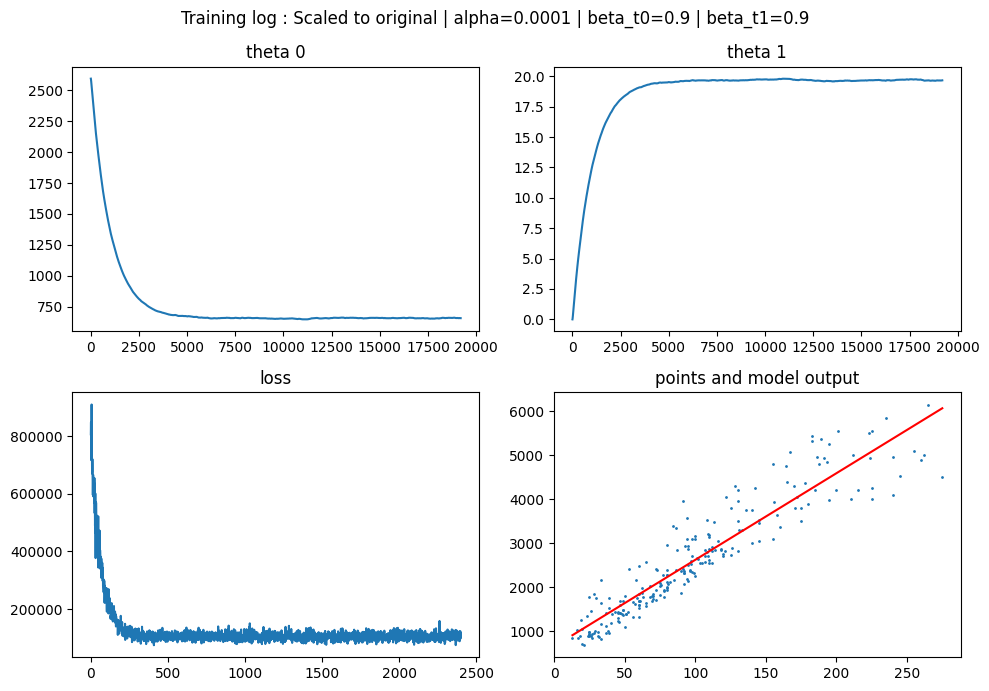

In [26]:
# Scaling evolutions to original
# To make comparisons to non-normalized-input version of the same approach

t0_evolution_std = np.array(t0_evolution)
t1_evolution_std = np.array(t1_evolution)
loss_evolution_std = np.array(loss_evolution)

# Convert thetas history back to original scale
t1_evolution_original = (y_std / x_std) * t1_evolution_std
t0_evolution_original = y_mean + y_std * t0_evolution_std - t1_evolution_original * x_mean

# Convert MSE-like loss back to original scale:
# Since the loss has a square operation, std is also squared
loss_evolution_original = loss_evolution_std * (y_std ** 2)

plot_training_log(
    loss_evolution_original,
    t0_evolution_original,
    t1_evolution_original,
    living_area,
    rent_price,
    title=': Scaled to original | alpha=' + str(alpha) +" | beta_t0=" + str(beta_momentum_t0) + " | beta_t1=" + str(beta_momentum_t1)
)

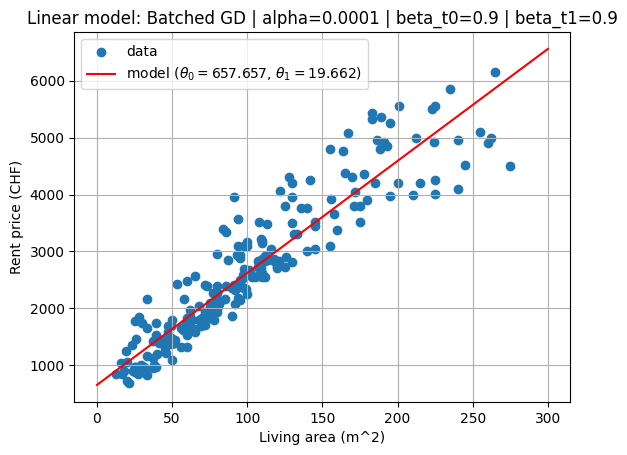

In [27]:
title_str = '| alpha=' + str(alpha) +" | beta_t0=" + str(beta_momentum_t0) + " | beta_t1=" + str(beta_momentum_t1)
x_curve = np.array(np.linspace(0, 300, 200))
plot_data_prediction(
    x_points=living_area,
    y_points=rent_price,
    x_curve=x_curve,
    y_curve=t0_original + t1_original * x_curve,
    x_title="Living area (m^2)",
    y_title="Rent price (CHF)",
    theta_0=t0_original,
    theta_1=t1_original,
    title="Linear model: Batched GD " + title_str,
)

#### Comparison table of training curves (`epochs=2400`)

|                                   Original inputs (different $\beta$) |                   STD -> Original Scaled Data (different $\beta$) |                        STD -> Original Scaled Data (same $\beta$) |
|------------------------------------------------------------------:|------------------------------------------------------------------:|------------------------------------------------------------------:|
| 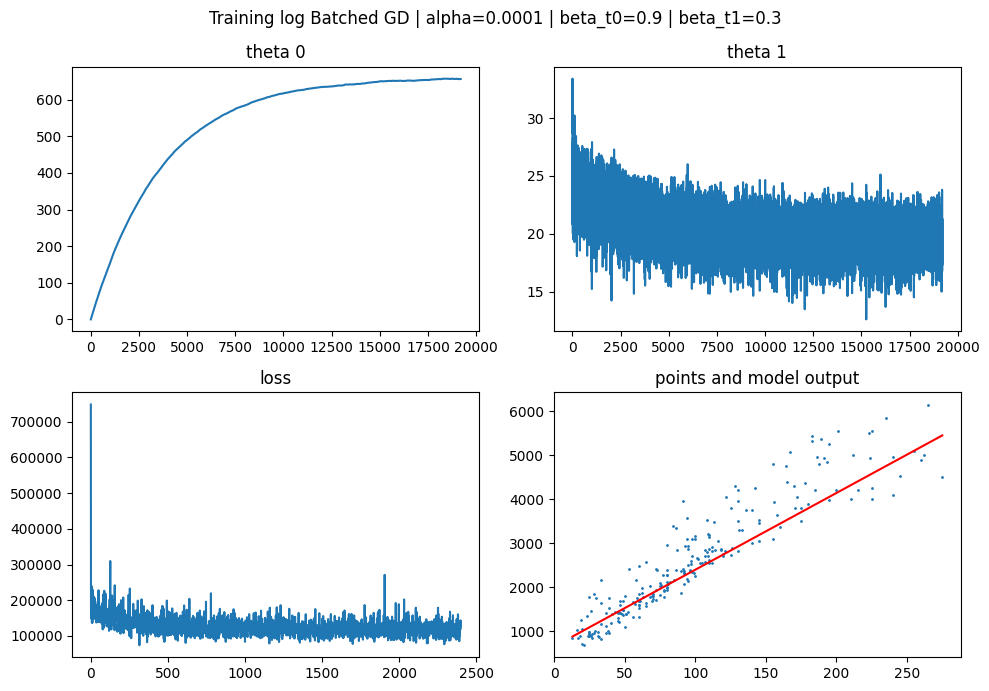 | 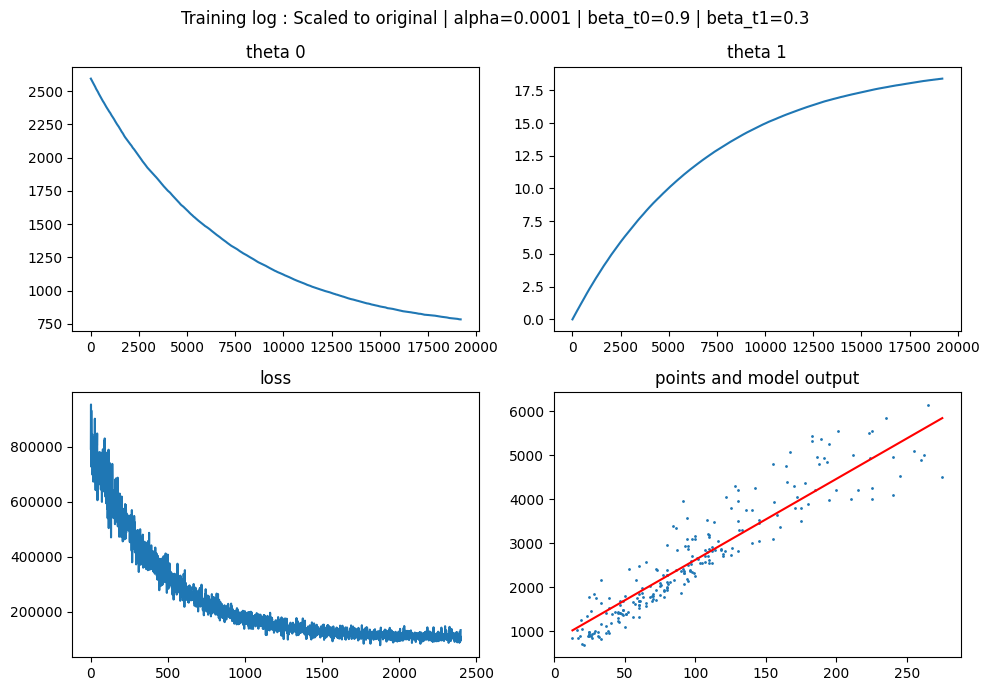 | 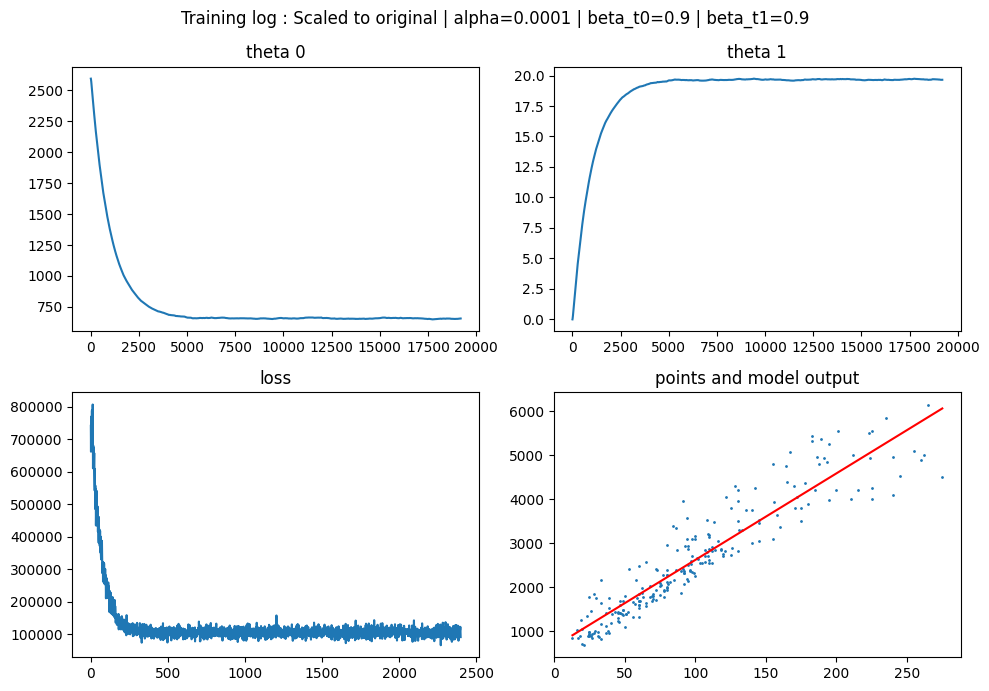 |


#### Comparison of experiments: Original vs Standardized data
Compared experiments are done with Batched GD algorithm with momentum optimization (part 5.2).

| Value                | Closed solution | Original inputs | STD + scaling to original, $\beta_0 \not= \beta_1$ | STD + scaling to original, $\beta_0 = \beta_1$ |
|----------------------|----------------:|----------------:|---------------------------------------------------:|-----------------------------------------------:|
| epochs               |               - |            2400 |                                               2400 |                                           2400 |
| $\alpha$             |               - |            1e-4 |                                               1e-4 |                                           1e-4 |
| $\beta_0$            |               - |             0.9 |                                                0.9 |                                            0.9 |
| $\beta_1$            |               - |             0.3 |                                            **0.3** |                                        **0.9** |
| $\theta_0$ intercept |         657.689 |     ~ 652...654 |                                    **~ 783...784** |                                      **~ 656** |
| $\theta_1$ slope     |          19.661 |       ~ 17...22 |                                               ~ 18 |                                         ~ 19.7 |
| Loss                 |      104'915.13 |    ~ 106...140K |                                              ~108K |                                         ~ 105K |
| Time                 |            < 1s |            < 4s |                                               < 6s |                                           < 6s |



### Our observations

- Choosing different momentum coefficients $\beta$ for $\theta_0$ and $\theta_1$ is not necessary after standardization: the gradients become comparable in magnitude, so both parameters evolve on similar scales and converge accordingly.

- **Slope $\theta_1$ shows more stable convergence after standardization**: its evolution curve becomes smooth, while without standardization it exhibits noticeable oscillations.

- **Loss converges more smoothly after standardization**: the evolution becomes more stable, without the sharp initial drop observed in the non-standardized case, and with reduced oscillation amplitude.

- Without standardization, different momentum coefficients were required because the gradients of $\theta_0$ and $\theta_1$ differed significantly in magnitude. **Standardization removes this imbalance, allowing the use of a single momentum parameter**.

- The poor estimate of $\theta_0$ in the $\beta_0 \not= \beta_1$ case highlights that even with standardized data inappropriate hyperparameter choice can  lead to suboptimal results.

<div class="alert alert-block alert-info">
<b>Conclusion:</b> standardization improves the conditioning of the optimization problem, balances gradient magnitudes, and enables more stable and efficient gradient-based optimization.
</div>

----
## 6.2 Quadratic (or squared, or 2nd Order) Model
A second-order model extends linear regression by adding a square term $x^2$, which allows the model to capture curvature while preserving linearity in the parameters and keeping the same closed form solution.


\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x + \theta_{2} x^2
\end{equation*}


Similarly to the linear case, this optimization problem has a closed form solution. We need to extend the matrix $X$ so it includes the square term:

$$
X =
\begin{bmatrix}
1 & x_n & x_n^2
\end{bmatrix}_{n=1}^N
$$

The optimal parameters are given by:

$$
\theta = (X^T X)^{-1} X^T y
$$

### Closed form solution for 2nd order model

In [28]:
# Closed-form solution for 2nd order / quadratic regression
# Model: y_hat = theta_0 + theta_1 * x + theta_2 * x^2

x = living_area
y = rent_price

# Extend matrix: [1, x, x^2]
X = np.column_stack([
    np.ones(len(x)),
    x,
    x ** 2
])

# Normal equation
theta, *_ = np.linalg.lstsq(X, y, rcond=None)
theta_0, theta_1, theta_2 = theta

print("Closed-form quadratic regression parameters:")
print("intercept (theta_0):", theta_0)
print("slope     (theta_1):", theta_1)
print("curvature (theta_2):", theta_2)

# Predictions
y_hat_quad = theta_0 + theta_1 * x + theta_2 * (x ** 2)

# Loss / metrics
J_quad = mse_loss(y_hat_quad, y)
rmse_quad = rmse_loss(y_hat_quad, y)
mae_quad = mae_loss(y_hat_quad, y)
mape_quad = mape_loss(y_hat_quad, y)

print("Loss:", J_quad)
print("RMSE:", f"{rmse_quad:.3f}")
print("MAE :", f"{mae_quad:.3f}")
print("MAPE:", f"{mape_quad * 100:.2f}%")

Closed-form quadratic regression parameters:
intercept (theta_0): 259.5618527517252
slope     (theta_1): 28.411826309203224
curvature (theta_2): -0.03483101979527748
Loss: 94056.03163909208
RMSE: 433.719
MAE : 340.799
MAPE: 13.85%


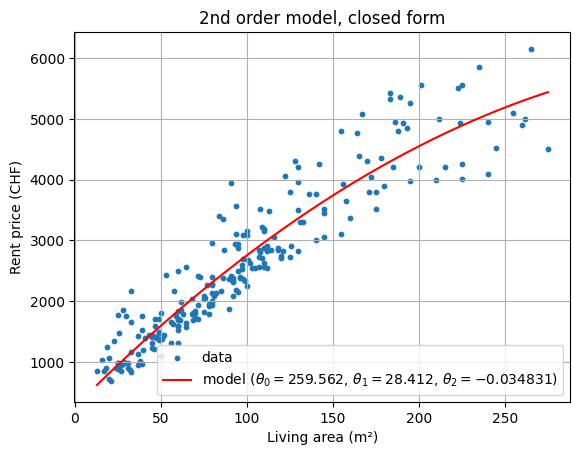

In [29]:
x_curve = np.array(np.linspace(0, 300, 231))
plot_data_prediction_squared(
    living_area,
    rent_price,
    theta_0=theta_0,
    theta_1=theta_1,
    theta_2=theta_2,
    x_title="Living area (m²)",
    y_title="Rent price (CHF)",
    title="2nd order model, closed form",
)

### Computational graph
Computational graph for the second-order model is the following:

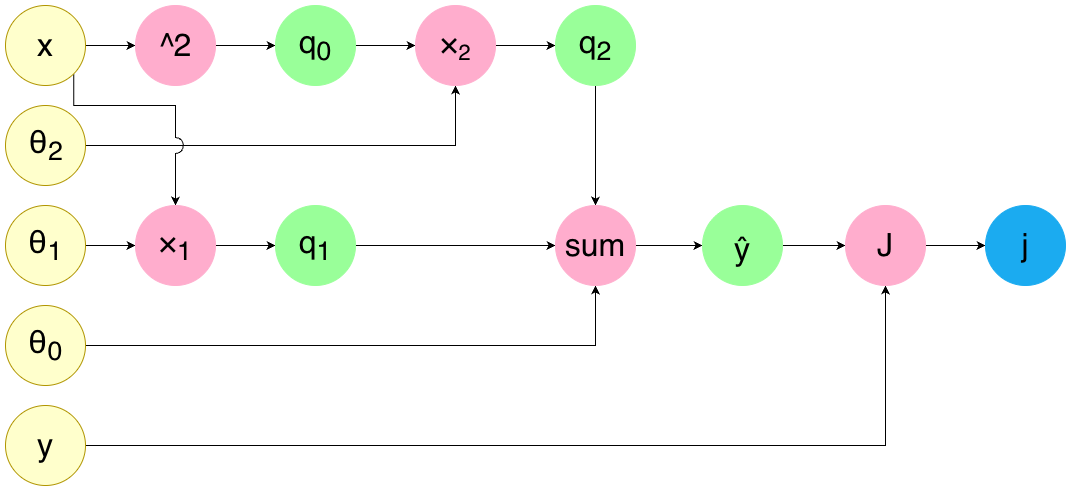

Diagram is made via [draw.io](https://app.diagrams.net/)

<div class="alert alert-block alert-warning">
<b>Note:</b> since we have two different multiplication operations, we number them as the 1st and the 2nd one in the graph.
</div>

Let's implement this model as a computational graph, like we did before:

In [30]:
# first create all ValueNode objects
theta_0_node = ValueNode()
theta_1_node = ValueNode()
theta_2_node = ValueNode()
y_node = ValueNode()
x_node = ValueNode()
q0_node = ValueNode()
q1_node = ValueNode()
q2_node = ValueNode()
y_hat_node = ValueNode()
j_node = ValueNode()

# then create all <Operator>Node objects
square_node = SquareNode(x_node, q0_node)
mult_node_1 = MultiplyNode(x_node, theta_1_node, q1_node)
mult_node_2 = MultiplyNode(q0_node, theta_2_node, q2_node)
sum_node = AddNode([q2_node, q1_node, theta_0_node], y_hat_node)
loss_node = MSELossNode(y_hat_node, y_node, j_node)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg1 = CompGraph([x_node, theta_0_node, theta_1_node, theta_2_node, y_node], [j_node])

In [31]:
# try a forward pass with dummy values
cg1.reset_values()
cg1.forward([2.0, 0.0, 1.0, 3.0, 14.0]) # 0 + 1*2 + 3*4 = 14, so loss should be 0.0
print(j_node.v)  # should give 0.0

0.0


In [32]:
cg1.backward()
print(y_node.v) # should give 14.0, the true value

14.0


### Training Loop
As before, we use Batched GD with momentum optimization to train the model. It is the same training loop as in task 5.2, but with the new computational graph.

In [138]:
# Normalization of inputs

x_mean = living_area.mean()
x_std = living_area.std()

y_mean = rent_price.mean()
y_std = rent_price.std()

living_area_std = (living_area - x_mean) / x_std
rent_price_std = (rent_price - y_mean) / y_std

In [139]:
alpha = 1e-4
# With standardized data, betas do not have to be asymmetric
beta_momentum_t0 = 0.9
beta_momentum_t1 = 0.9
beta_momentum_t2 = 0.9

epochs = 2400
momentum_t0 = 0.0
momentum_t1 = 0.0
momentum_t2 = 0.0

batch_size = 32
N = len(living_area_std)

# In STANDARDIZED coordinates:
# rent_price_std_hat = t0 + t1 * living_area_std + t2 * living_area_std ** 2
t0 = 0.0
t1 = 0.0
t2 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []
t2_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for step in range(n_steps):

        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_grad_t2 = 0.0
        batch_loss = 0.0

        # working with a batch of samples
        for _ in range(batch_size):
            n = random.choice(range(0, N))

            cg1.reset_values()

            cg1.forward([living_area_std[n], t0, t1, t2, rent_price_std[n]])
            cg1.backward()

            batch_grad_t0 += theta_0_node.grad_v
            batch_grad_t1 += theta_1_node.grad_v
            batch_grad_t2 += theta_2_node.grad_v
            batch_loss += j_node.v

        # average gradients over the batch
        batch_grad_t0 /= batch_size
        batch_grad_t1 /= batch_size
        batch_grad_t2 /= batch_size
        batch_loss /= batch_size

        # momentum update
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * batch_grad_t0
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * batch_grad_t1
        momentum_t2 = beta_momentum_t2 * momentum_t2 + alpha * batch_grad_t2

        # update parameters once per batch
        t0 -= momentum_t0
        t1 -= momentum_t1
        t2 -= momentum_t2

        epoch_loss += batch_loss

        t0_evolution.append(t0)
        t1_evolution.append(t1)
        t2_evolution.append(t2)

    loss_evolution.append(epoch_loss / n_steps)

In [140]:
# CONVERTING STD -> ORIGINAL SCALE (2nd order model)

# STD:
# y_std_hat = t0 + t1 * x_std + t2 * x_std^2
#
# ORIGINAL:
# y_hat = t0_original + t1_original * x + t2_original * x^2

# Parameters
t2_original = (y_std / (x_std ** 2)) * t2
t1_original = (y_std / x_std) * t1 - 2 * t2_original * x_mean
t0_original = (
    y_mean
    + y_std * t0
    - (y_std / x_std) * t1 * x_mean
    + t2_original * (x_mean ** 2)
)

print("STANDARDIZED parameters:")
print("theta_0_std:", t0)
print("theta_1_std:", t1)
print("theta_2_std:", t2)

print("\nORIGINAL-SCALE parameters:")
print("theta_0:", t0_original)
print("theta_1:", t1_original)
print("theta_2:", t2_original)

# Predictions
y_hat_std = t0 + t1 * living_area_std + t2 * (living_area_std ** 2)
y_hat = y_hat_std * y_std + y_mean

# Loss
J_std = mse_loss(y_hat_std, rent_price_std)
J_original = mse_loss(y_hat, rent_price)

print("\nSTD Loss:", J_std)
print("ORIGINAL Loss:", J_original)

rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)

print()
print("RMSE:", f"{rmse:.3f}")
print("MAE :", f"{mae:.3f}")
print("MAPE:", f"{mape * 100:.2f}%")


STANDARDIZED parameters:
theta_0_std: 0.0978536680525691
theta_1_std: 1.022582014349379
theta_2_std: -0.10178065589828744

ORIGINAL-SCALE parameters:
theta_0: 248.09196555767414
theta_1: 28.59543889674214
theta_2: -0.035701681561452106

STD Loss: 0.058551708849113884
ORIGINAL Loss: 94077.43498390757

RMSE: 433.768
MAE : 339.806
MAPE: 13.78%


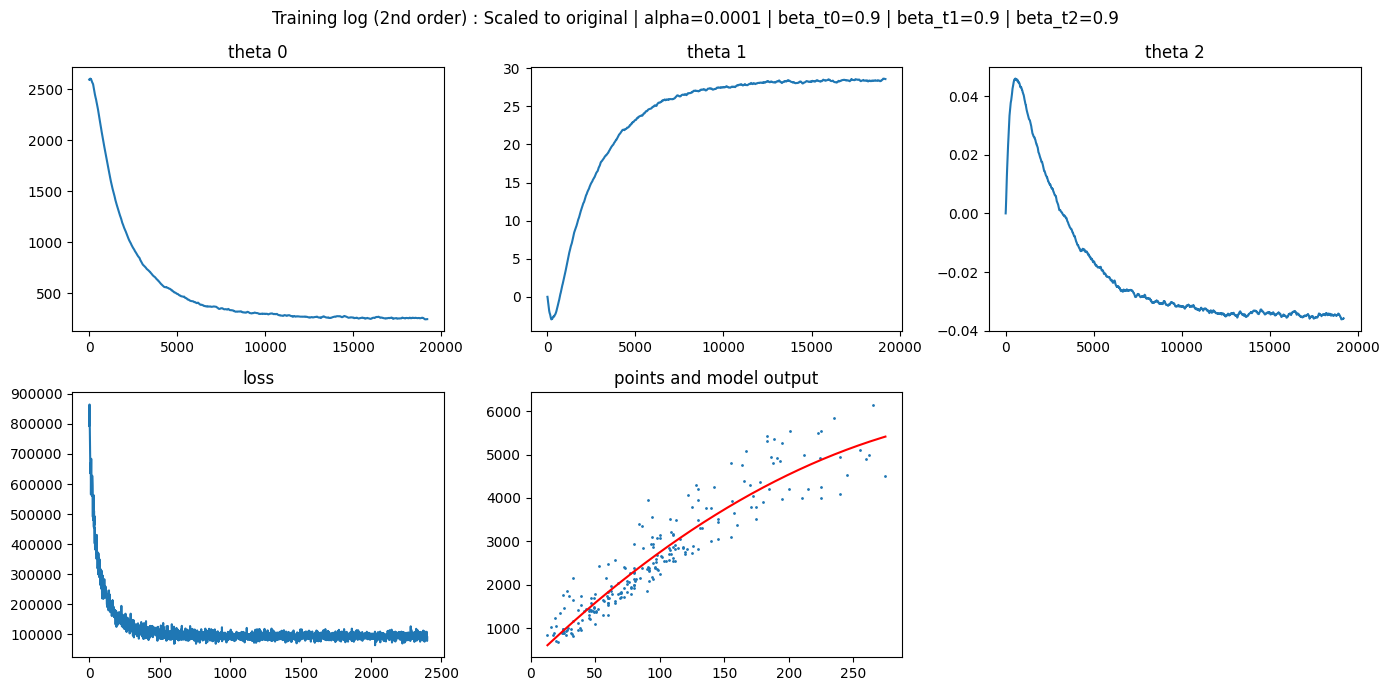

In [141]:
# Scaling evolutions to original scale
t0_evolution_std = np.array(t0_evolution)
t1_evolution_std = np.array(t1_evolution)
t2_evolution_std = np.array(t2_evolution)
loss_evolution_std = np.array(loss_evolution)

t2_evolution_original = (y_std / (x_std ** 2)) * t2_evolution_std
t1_evolution_original = (
    (y_std / x_std) * t1_evolution_std
    - 2 * t2_evolution_original * x_mean
)
t0_evolution_original = (
    y_mean
    + y_std * t0_evolution_std
    - (y_std / x_std) * t1_evolution_std * x_mean
    + t2_evolution_original * (x_mean ** 2)
)

# Loss scaling
loss_evolution_original = loss_evolution_std * (y_std ** 2)

plot_training_log_squared(
    loss_evolution_original,
    t0_evolution_original,
    t1_evolution_original,
    t2_evolution_original,
    living_area,
    rent_price,
    title=': Scaled to original | alpha=' + str(alpha) +
          " | beta_t0=" + str(beta_momentum_t0) +
          " | beta_t1=" + str(beta_momentum_t1) +
          " | beta_t2=" + str(beta_momentum_t2)
)

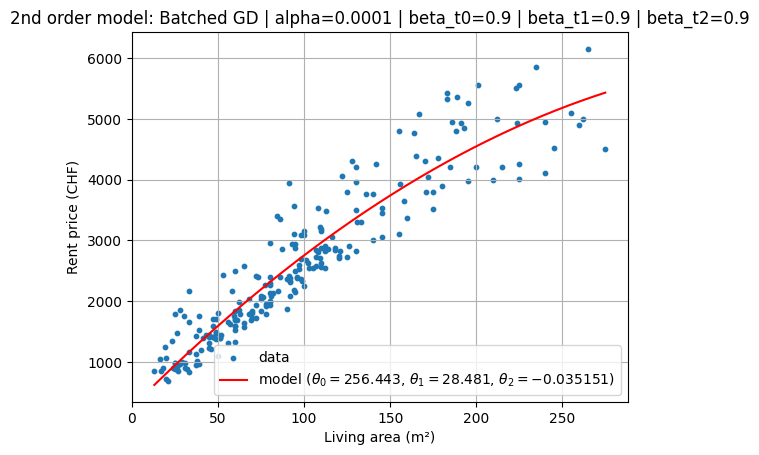

In [37]:
title_str = '| alpha=' + str(alpha) +" | beta_t0=" + str(beta_momentum_t0) + " | beta_t1=" + str(beta_momentum_t1) + " | beta_t2=" + str(beta_momentum_t2)
plot_data_prediction_squared(
    living_area,
    rent_price,
    theta_0=t0_original,
    theta_1=t1_original,
    theta_2=t2_original,
    x_title="Living area (m²)",
    y_title="Rent price (CHF)",
    title="2nd order model: Batched GD "+title_str,
)


| Model type            |                                              Closed form solution |                              Batched GD with data standardization |
|-----------------------|------------------------------------------------------------------:|------------------------------------------------------------------:|
| Linear (1st order)    | 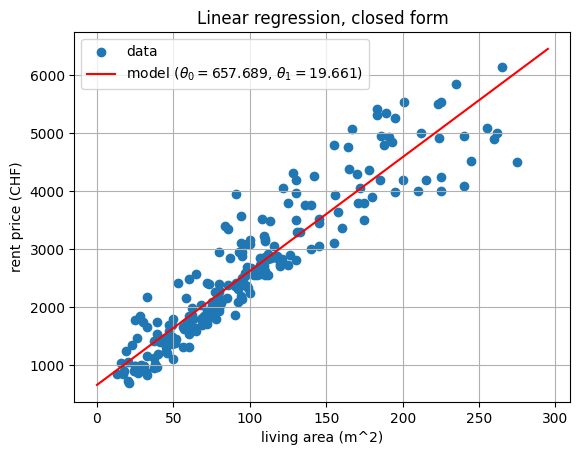 | 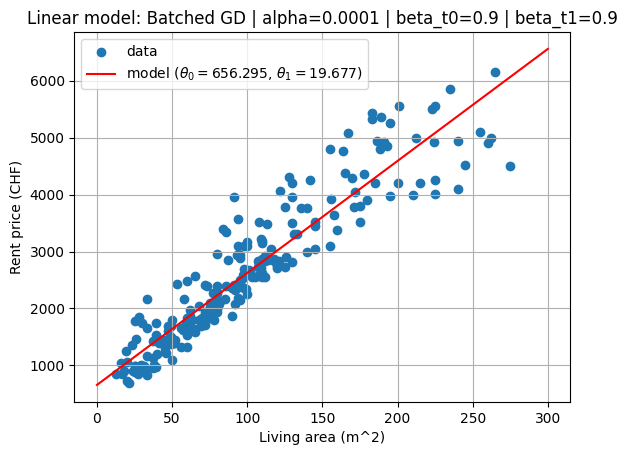 |
| Quadratic (2nd order) | 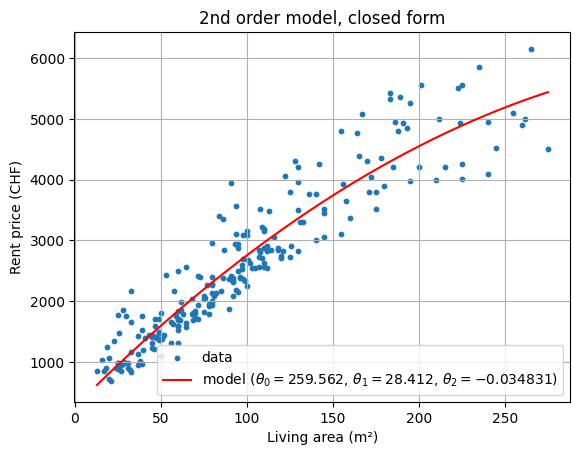 | 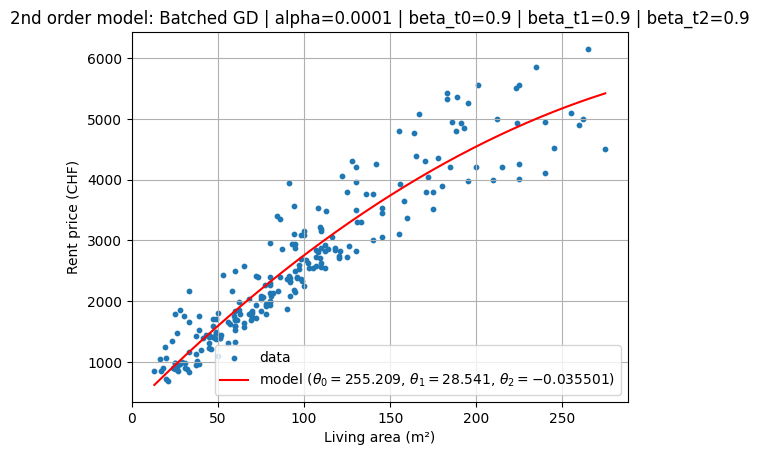 |

### Our observations
Comparing linear and 2nd order models with closed form solutions:

| Value                | LINEAR, Closed form | LINEAR, Batched GD with STD | QUADRATIC, Closed form | QUADRATIC, Batched GD with STD |
|----------------------|--------------------:|----------------------------:|-----------------------:|-------------------------------:|
| epochs               |                   - |                        2400 |                      - |                           2400 |
| $\alpha$             |                   - |                        1e-4 |                      - |                           1e-4 |
| $\beta_0$            |                   - |                         0.9 |                      - |                            0.9 |
| $\beta_1$            |                   - |                         0.9 |                      - |                            0.9 |
| $\beta_2$            |                   - |                           - |                      - |                            0.9 |
| $\theta_0$ intercept |             657.689 |                       ~ 656 |                259.562 |                    ~ 253...259 |
| $\theta_1$ slope     |              19.661 |                        19.7 |                 28.412 |                  ~ 28.3...28.5 |
| $\theta_2$ curvature |                   - |                           - |             **-0.035** |                   **~ -0.035** |
| Loss                 |      **104'915.13** |                  **~ 105K** |          **94'056.03** |                      **~ 94K** |
| RMSE                 |             458.072 |                       ~ 458 |                433.719 |                        ~ 433.7 |
| MAE                  |             347.377 |                       ~ 347 |                340.799 |                    ~ 340...341 |
| MAPE                 |              14.63% |                      ~ 14.6 |                 13.85% |                ~ 13.8%...13.9% |
| Time                 |                < 1s |                         <6s |                   < 1s |                           < 5s |



#### Conclusions
- **The quadratic model provides a better fit to the data.** Compared to the linear model, the quadratic model reduces all error metrics:
    * Loss decreases from ~105K to ~94K
    * RMSE decreases from ~458 to ~434
    * MAE and MAPE also improve

    This indicates that **the relationship between living area and rent is not purely linear** and benefits from modeling curvature.
- The learned curvature $\theta_2$ is small, but meaningful.

    The coefficient $\theta_2 \approx -0.035$ is relatively small in magnitude, but consistently found by both closed solution and GD. This suggests a mild concave relationship (diminishing returns effect): **rent price increases with living area, but at a decreasing rate**.


## Early Stopping
TODO Lucas

## Learning Rate Decay on Plateau
TODO Lucas

## Extra:

Just for fun we wanted to combine some of the versions together an look at the combined final result. Without taking long time for hyperparameter tuning (which would be necessary to recieve the optimum result).

The model ia a combination of:
- Data normalization
- Quadratic model
- Batched gradient descent
- Momentum optimizer
- Early stopping

Epoch 454: loss plateau detected.Learning rate reduced from 0.0001 to 8e-05.
Epoch 593: loss plateau detected.Learning rate reduced from 8e-05 to 6.400000000000001e-05.
Epoch 673: loss plateau detected.Learning rate reduced from 6.400000000000001e-05 to 5.120000000000001e-05.
Early stopping triggered at epoch: 713
STANDARDIZED parameters:
theta_0_std: 0.02332788703690584
theta_1_std: 0.9487924053179807
theta_2_std: -0.048315002084920025

ORIGINAL-SCALE parameters:
theta_0: 488.831863249207
theta_1: 23.345002705901216
theta_2: -0.01694749168054568

STD Loss: 0.06100261789626806
ORIGINAL Loss: 98015.41119446197

RMSE: 442.754
MAE : 335.837
MAPE: 13.75%


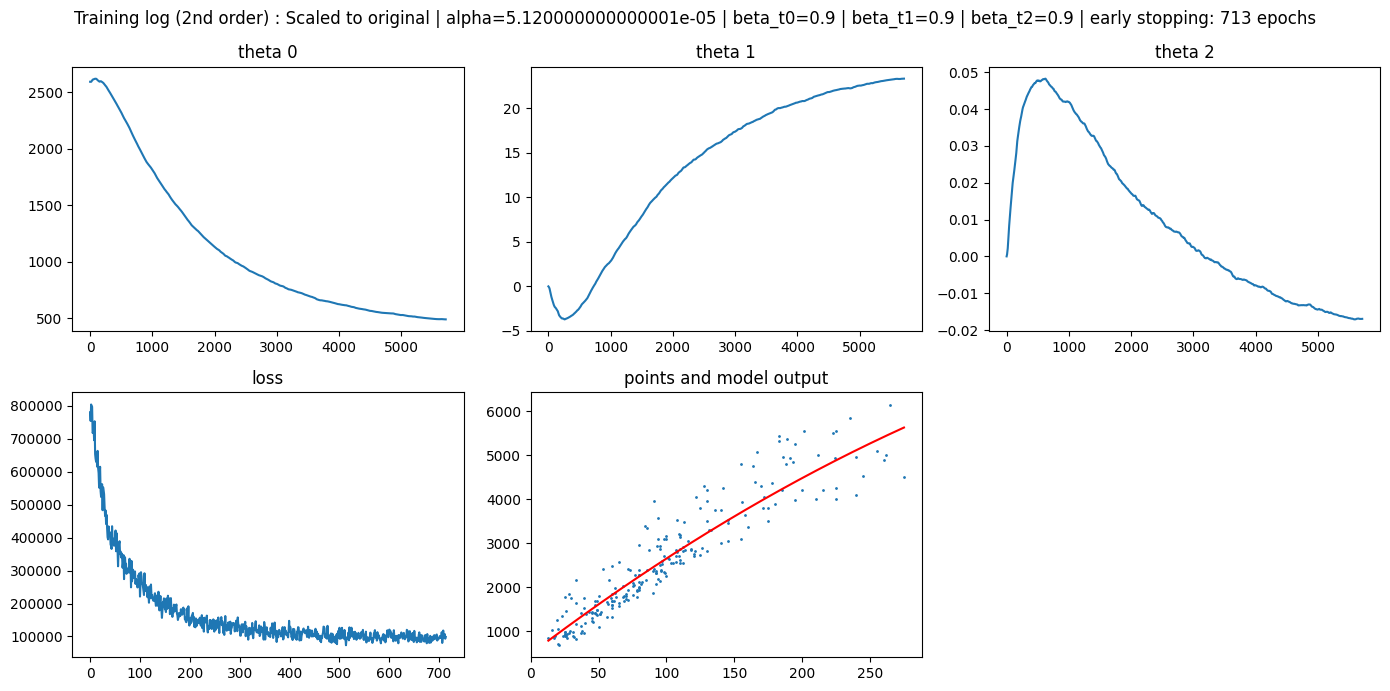

In [237]:
# Normalization of inputs

x_mean = living_area.mean()
x_std = living_area.std()

y_mean = rent_price.mean()
y_std = rent_price.std()

living_area_std = (living_area - x_mean) / x_std
rent_price_std = (rent_price - y_mean) / y_std


# TRAINING LOOP:
alpha = 1e-4
# With standardized data, betas do not have to be asymmetric
beta_momentum_t0 = 0.9
beta_momentum_t1 = 0.9
beta_momentum_t2 = 0.9

# learning rate decay
lr_patience = 80
lr_decay_factor = 0.8
min_alpha = 1e-6
lr_min_delta = 1e-4
plateau_counter = 0
lr_best_loss = float('inf')

epochs = 5000
momentum_t0 = 0.0
momentum_t1 = 0.0
momentum_t2 = 0.0

batch_size = 32
N = len(living_area_std)

# In STANDARDIZED coordinates:
# rent_price_std_hat = t0 + t1 * living_area_std + t2 * living_area_std ** 2
t0 = 0.0
t1 = 0.0
t2 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []
t2_evolution = []

# early stopping settings
patience = 200 # number of epochs to wait before early stopping is triggered
es_min_delta = 1e-8 # minimum improvement in the loss to qualify as a change --> with standardized data, the loss is smaller than in the prevoius non-standardized version

es_best_loss = float('inf')
patience_counter = 0
stopped_epoch = None

for epoch in range(epochs):
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for step in range(n_steps):

        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_grad_t2 = 0.0
        batch_loss = 0.0

        # working with a batch of samples
        for _ in range(batch_size):
            n = random.choice(range(0, N))

            cg1.reset_values()

            cg1.forward([living_area_std[n], t0, t1, t2, rent_price_std[n]])
            cg1.backward()

            batch_grad_t0 += theta_0_node.grad_v
            batch_grad_t1 += theta_1_node.grad_v
            batch_grad_t2 += theta_2_node.grad_v
            batch_loss += j_node.v

        # average gradients over the batch
        batch_grad_t0 /= batch_size
        batch_grad_t1 /= batch_size
        batch_grad_t2 /= batch_size
        batch_loss /= batch_size

        # momentum update
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * batch_grad_t0
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * batch_grad_t1
        momentum_t2 = beta_momentum_t2 * momentum_t2 + alpha * batch_grad_t2

        # update parameters once per batch
        t0 -= momentum_t0
        t1 -= momentum_t1
        t2 -= momentum_t2

        epoch_loss += batch_loss

        t0_evolution.append(t0)
        t1_evolution.append(t1)
        t2_evolution.append(t2)

    avg_epoch_loss = epoch_loss / n_steps
    loss_evolution.append(avg_epoch_loss)

    # early stopping mechanism
    es_improvement = es_best_loss - avg_epoch_loss

    if es_improvement > es_min_delta:
        es_best_loss = avg_epoch_loss
        patience_counter = 0  # reset counter
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        stopped_epoch = epoch
        print(f"Early stopping triggered at epoch: {epoch}")
        break # interrupting the trainng loop when early stopping conditions are met

    # reduce learning rate on plateau
    lr_improvement = lr_best_loss - avg_epoch_loss

    if lr_improvement > lr_min_delta:
        lr_best_loss = avg_epoch_loss
        plateau_counter = 0 # reset plateau counter
    else:
        plateau_counter += 1
    
    if plateau_counter >= lr_patience:
        old_alpha = alpha
        alpha = max(alpha * lr_decay_factor, min_alpha) # change learning rate with decay factor but not smaller than min_alpha
        plateau_counter = 0 # reset plateau counter

        print(
            f"Epoch {epoch}: loss plateau detected."
            f"Learning rate reduced from {old_alpha} to {alpha}."
        )

# EVALUATION:
# CONVERTING STD -> ORIGINAL SCALE (2nd order model)

# STD:
# y_std_hat = t0 + t1 * x_std + t2 * x_std^2
#
# ORIGINAL:
# y_hat = t0_original + t1_original * x + t2_original * x^2

# Parameters
t2_original = (y_std / (x_std ** 2)) * t2
t1_original = (y_std / x_std) * t1 - 2 * t2_original * x_mean
t0_original = (
    y_mean
    + y_std * t0
    - (y_std / x_std) * t1 * x_mean
    + t2_original * (x_mean ** 2)
)

print("STANDARDIZED parameters:")
print("theta_0_std:", t0)
print("theta_1_std:", t1)
print("theta_2_std:", t2)

print("\nORIGINAL-SCALE parameters:")
print("theta_0:", t0_original)
print("theta_1:", t1_original)
print("theta_2:", t2_original)

# Predictions
y_hat_std = t0 + t1 * living_area_std + t2 * (living_area_std ** 2)
y_hat = y_hat_std * y_std + y_mean

# Loss
J_std = mse_loss(y_hat_std, rent_price_std)
J_original = mse_loss(y_hat, rent_price)

print("\nSTD Loss:", J_std)
print("ORIGINAL Loss:", J_original)

rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)

print()
print("RMSE:", f"{rmse:.3f}")
print("MAE :", f"{mae:.3f}")
print("MAPE:", f"{mape * 100:.2f}%")

# Scaling evolutions to original scale
t0_evolution_std = np.array(t0_evolution)
t1_evolution_std = np.array(t1_evolution)
t2_evolution_std = np.array(t2_evolution)
loss_evolution_std = np.array(loss_evolution)

t2_evolution_original = (y_std / (x_std ** 2)) * t2_evolution_std
t1_evolution_original = (
    (y_std / x_std) * t1_evolution_std
    - 2 * t2_evolution_original * x_mean
)
t0_evolution_original = (
    y_mean
    + y_std * t0_evolution_std
    - (y_std / x_std) * t1_evolution_std * x_mean
    + t2_evolution_original * (x_mean ** 2)
)

# Loss scaling
loss_evolution_original = loss_evolution_std * (y_std ** 2)

plot_training_log_squared(
    loss_evolution_original,
    t0_evolution_original,
    t1_evolution_original,
    t2_evolution_original,
    living_area,
    rent_price,
    title=': Scaled to original | alpha=' + str(alpha) +
          " | beta_t0=" + str(beta_momentum_t0) +
          " | beta_t1=" + str(beta_momentum_t1) +
          " | beta_t2=" + str(beta_momentum_t2) +
          " | early stopping: " + str(stopped_epoch) + " epochs"
)

### Our observations
Comparing 2nd order model with early stopping to the closed form solution:

| Value                | QUADRATIC, Closed form | QUADRATIC, Batched GD with STD | QUADRATIC, Batched GD with STD and early stopping |
|----------------------|-----------------------:|-------------------------------:|--------------------------------------------------:|
| epochs               |                      - |                           2400 |                                        ~ 700...800|
| $\alpha$             |                      - |                           1e-4 |                                              1e-4 |
| $\beta_0$            |                      - |                            0.9 |                                               0.9 |
| $\beta_1$            |                      - |                            0.9 |                                               0.9 |
| $\beta_2$            |                      - |                            0.9 |                                               0.9 |
| `lr_patience`        |                      - |                              - |                                                50 |
| `lr_min_delta`       |                      - |                              - |                                              1e-4 |
| `es_patience`        |                      - |                              - |                                               200 |
| `es_min_delta`       |                      - |                              - |                                              1e-8 |
| $\theta_0$ intercept |                259.562 |                    ~ 253...259 |                                       ~ 400...450 |
| $\theta_1$ slope     |                 28.412 |                  ~ 28.3...28.5 |                                         ~ 24...25 |
| $\theta_2$ curvature |             **-0.035** |                   **~ -0.035** |                                       **~ -0.021** |
| Loss                 |          **94'056.03** |                      **~ 94K** |                                        **~ 97K** |
| RMSE                 |                433.719 |                        ~ 433.7 |                                             ~ 440 |
| MAE                  |                340.799 |                    ~ 340...341 |                                             ~ 335 |
| MAPE                 |                 13.85% |                ~ 13.8%...13.9% |                                           ~ 13.7% |
| Time                 |                   < 1s |                           < 5s |                                              < 2s |

- Early stopping gets triggert after ~700-800 epochs and decreases training time down to < 2s.
- $\theta_1$ and $ \theta_2$ are similar but **$\theta_0$ has a large differnce** which leads to the conclusion that in this case the location of the intercept $\theta_0$ is not that important for the overall model.
- The other measurement values Loss, RMSE, MAE and MAPE are as expected a bit worse than after 2400 epochs.

# External Resources
1. Andrew Ng, Stanford Lecture Notes: https://cs229.stanford.edu/notes2022fall/main_notes.pdf
2. SciKit Learn documentation: https://scikit-learn.org/stable/modules/preprocessing.html
3. draw.io for CG diagrams: https://app.diagrams.net/